In [1]:
# Import Libraries and Dataset

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    chi2_contingency,
    ttest_ind,
    pointbiserialr
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)


# ==========================================================
# LOAD ORIGINAL DATASET
# ==========================================================

DATA_PATH = r"C:\Users\dukki\Customer Satisfaction.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

Dataset shape: (103904, 18)

First five rows:
       id  Gender  Age  Travel Category Travel Class  Distance Travelled  \
0   70172    Male   13  Personal Travel      Premium                 414   
1    5047    Male   25         Official     Business                 212   
2  110028  Female   26         Official     Business                1028   
3   24026  Female   25         Official     Business                 506   
4  119299    Male   61         Official     Business                 193   

   Departure/Arrival Rating  Booking Ease  Boarding Point  Food  Seat Comfort  \
0                       4.0           3.0             1.0   5.0           5.0   
1                       2.0           3.0             3.0   1.0           NaN   
2                       2.0           2.0             2.0   5.0           5.0   
3                       5.0           5.0             5.0   NaN           2.0   
4                       3.0           3.0             3.0   NaN           5.0   

   Enterta

Gender Distribution:
        Number of Travellers  Percentage
Gender                                  
Female                 52727       50.75
Male                   51177       49.25

Male-to-Female Ratio: 0.97


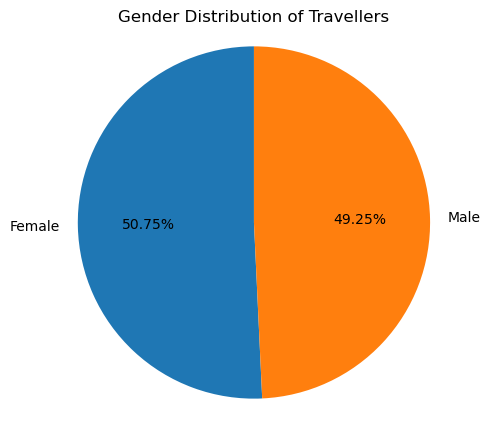

In [2]:
# ==========================================================
# The proportion of male to female travellers
# ==========================================================

gender_counts = df["Gender"].value_counts()

gender_percentage = (
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender_summary = pd.DataFrame({
    "Number of Travellers": gender_counts,
    "Percentage": gender_percentage
})

print("Gender Distribution:")
print(gender_summary)


# Male-to-female ratio
male_count = gender_counts.get("Male", 0)
female_count = gender_counts.get("Female", 0)

male_female_ratio = male_count / female_count

print(
    "\nMale-to-Female Ratio:",
    round(male_female_ratio, 2)
)


# Visualisation
plt.figure(figsize=(5, 5))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Gender Distribution of Travellers")
plt.axis("equal")
plt.show()

Satisfaction Counts by Gender:
Satisfaction  dissatisfied  satisfied
Gender                               
Female               30193      22534
Male                 28686      22491

Satisfaction Percentage by Gender:
Satisfaction  dissatisfied  satisfied
Gender                               
Female               57.26      42.74
Male                 56.05      43.95


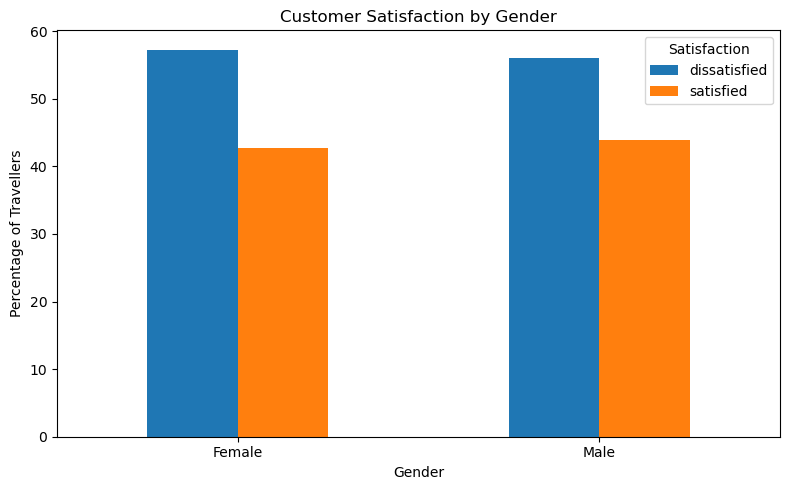


Chi-Square Test
Chi-square statistic: 15.4444
P-value: 8.496755458033522e-05
Degrees of freedom: 1
Result: Gender and satisfaction are statistically associated.


In [3]:
# ==========================================================
# How does gender relate to satisfaction levels?
# ==========================================================

gender_satisfaction_count = pd.crosstab(
    df["Gender"],
    df["Satisfaction"]
)

print("Satisfaction Counts by Gender:")
print(gender_satisfaction_count)


# Satisfaction percentage within each gender
gender_satisfaction = (
    pd.crosstab(
        df["Gender"],
        df["Satisfaction"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nSatisfaction Percentage by Gender:")
print(gender_satisfaction)


# Visual representation
gender_satisfaction.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Travellers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# Chi-square statistical test
# ----------------------------------------------------------

chi2, p_value, dof, expected = chi2_contingency(
    gender_satisfaction_count
)

print("\nChi-Square Test")
print("Chi-square statistic:", round(chi2, 4))
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print(
        "Result: Gender and satisfaction are "
        "statistically associated."
    )
else:
    print(
        "Result: No statistically significant "
        "association was found."
    )

Average Age: 39.38


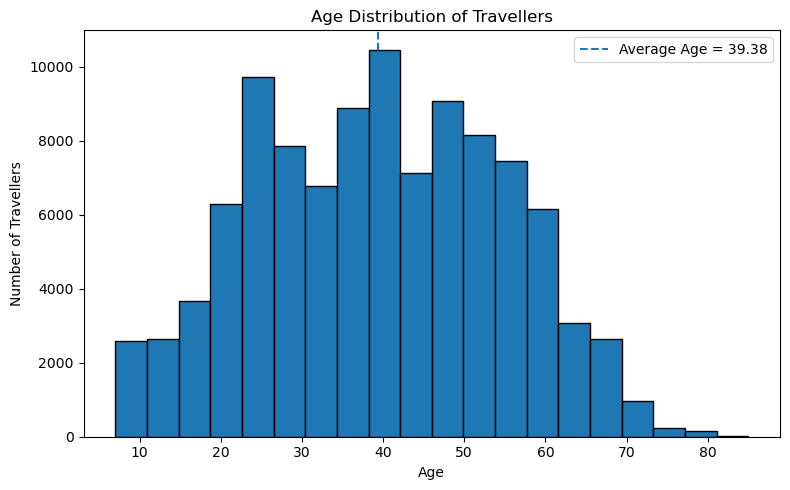

In [4]:
# ==========================================================
# What is the average age of travellers?
# ==========================================================

average_age = df["Age"].mean()

print(
    "Average Age:",
    round(average_age, 2)
)


# Visualise age distribution
plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    average_age,
    linestyle="--",
    label=f"Average Age = {average_age:.2f}"
)

plt.title("Age Distribution of Travellers")
plt.xlabel("Age")
plt.ylabel("Number of Travellers")
plt.legend()
plt.tight_layout()
plt.show()

Minimum Age: 7
Maximum Age: 85
Age Range: 78

Travellers by Age Group:
Age Bracket
Below 18     7931
18-30       24826
31-45       33252
46-60       29919
61+          7976
Name: count, dtype: int64


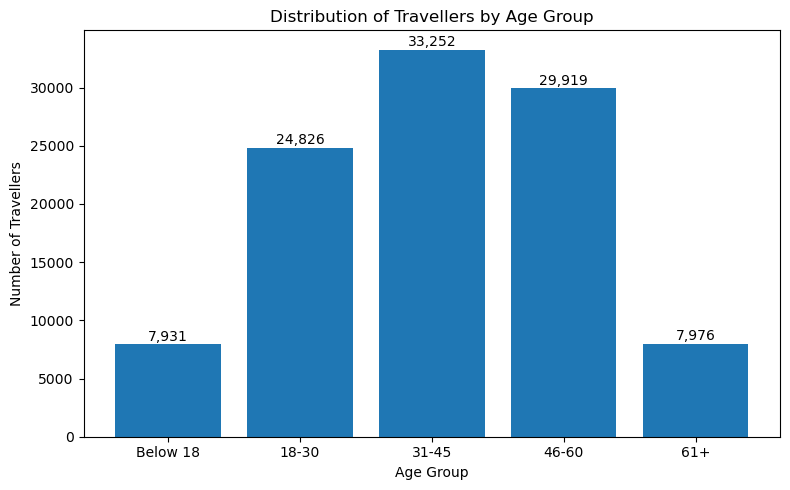

In [5]:
# ==========================================================
# What is the age range and age bracket distribution?
# ==========================================================

minimum_age = df["Age"].min()
maximum_age = df["Age"].max()

age_range = maximum_age - minimum_age

print("Minimum Age:", minimum_age)
print("Maximum Age:", maximum_age)
print("Age Range:", age_range)


# Create age brackets
age_bins = [
    -np.inf,
    17,
    30,
    45,
    60,
    np.inf
]

age_labels = [
    "Below 18",
    "18-30",
    "31-45",
    "46-60",
    "61+"
]

df["Age Bracket"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

age_counts = (
    df["Age Bracket"]
    .value_counts(sort=False)
)

print("\nTravellers by Age Group:")
print(age_counts)


# Visualisation
plt.figure(figsize=(8, 5))

bars = plt.bar(
    age_counts.index.astype(str),
    age_counts.values
)

plt.title("Distribution of Travellers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Travellers")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Travellers by Travel Category:
Travel Category
Official           71655
Personal Travel    32249
Name: count, dtype: int64


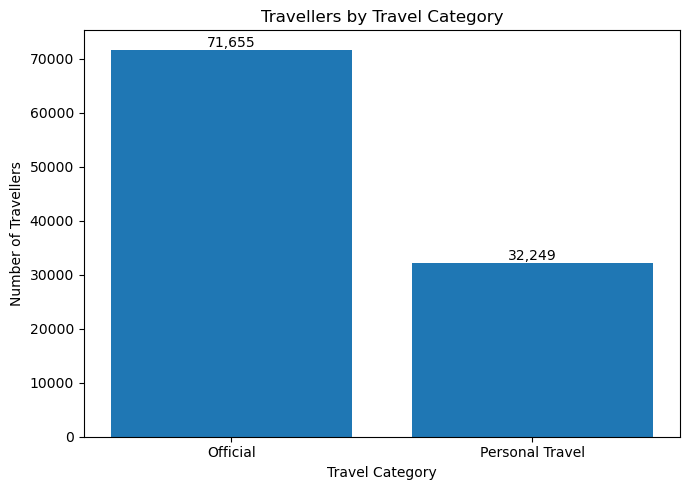

In [6]:
# ==========================================================
# Business/Official Travel versus Personal Travel
# ==========================================================

travel_counts = (
    df["Travel Category"]
    .value_counts()
)

print("Travellers by Travel Category:")
print(travel_counts)


# Visual representation
plt.figure(figsize=(7, 5))

bars = plt.bar(
    travel_counts.index,
    travel_counts.values
)

plt.title("Travellers by Travel Category")
plt.xlabel("Travel Category")
plt.ylabel("Number of Travellers")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Average Distance Travelled:
Travel Category
Official           1093.24
Personal Travel     633.66
Name: Distance Travelled, dtype: float64


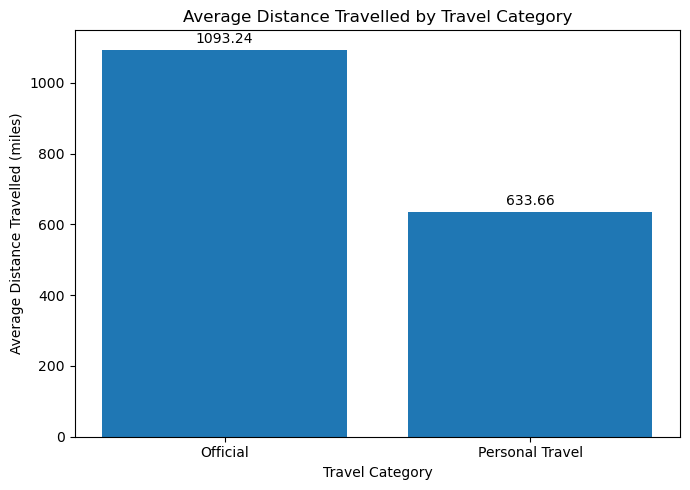

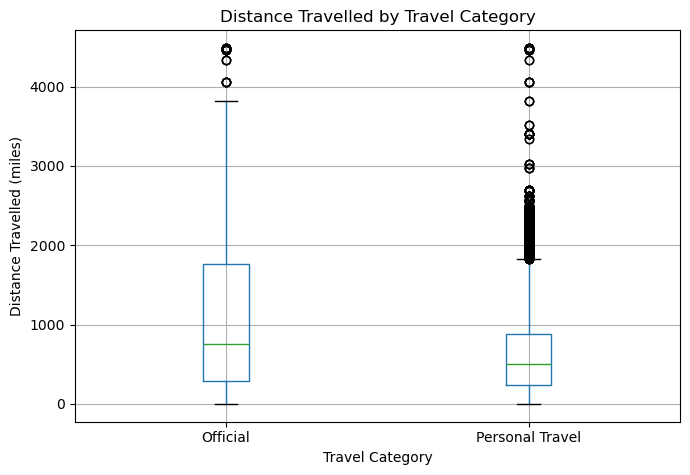

In [7]:
# ==========================================================
# Average distance travelled by travel category
# ==========================================================

average_distance = (
    df.groupby(
        "Travel Category"
    )["Distance Travelled"]
    .mean()
    .round(2)
)

print("Average Distance Travelled:")
print(average_distance)


# Bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    average_distance.index,
    average_distance.values
)

plt.title(
    "Average Distance Travelled by Travel Category"
)

plt.xlabel("Travel Category")
plt.ylabel("Average Distance Travelled (miles)")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# Additional box plot for rubric
df.boxplot(
    column="Distance Travelled",
    by="Travel Category",
    figsize=(7, 5)
)

plt.title(
    "Distance Travelled by Travel Category"
)

plt.suptitle("")
plt.xlabel("Travel Category")
plt.ylabel("Distance Travelled (miles)")
plt.tight_layout()
plt.show()

Average Seat Comfort Rating by Travel Class:
Travel Class
Business    3.76
Economy     3.14
Premium     3.18
Name: Seat Comfort, dtype: float64


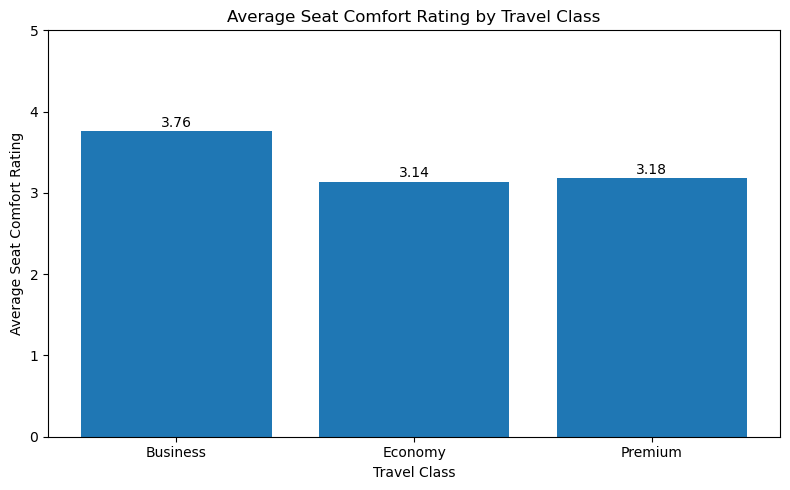

In [8]:
# ==========================================================
# Average Seat Comfort by Travel Class
# ==========================================================

seat_comfort_avg = (
    df.groupby(
        "Travel Class"
    )["Seat Comfort"]
    .mean()
    .round(2)
)

print(
    "Average Seat Comfort Rating by Travel Class:"
)

print(seat_comfort_avg)


# Visualisation
plt.figure(figsize=(8, 5))

bars = plt.bar(
    seat_comfort_avg.index,
    seat_comfort_avg.values
)

plt.title(
    "Average Seat Comfort Rating by Travel Class"
)

plt.xlabel("Travel Class")
plt.ylabel("Average Seat Comfort Rating")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Food Rating Summary:
              count  mean  median   std
Travel Class                           
Business      40412  3.32     3.0  1.28
Economy       37994  3.09     3.0  1.36

Average Food Rating:
Travel Class
Business    3.32
Economy     3.09
Name: Food, dtype: float64


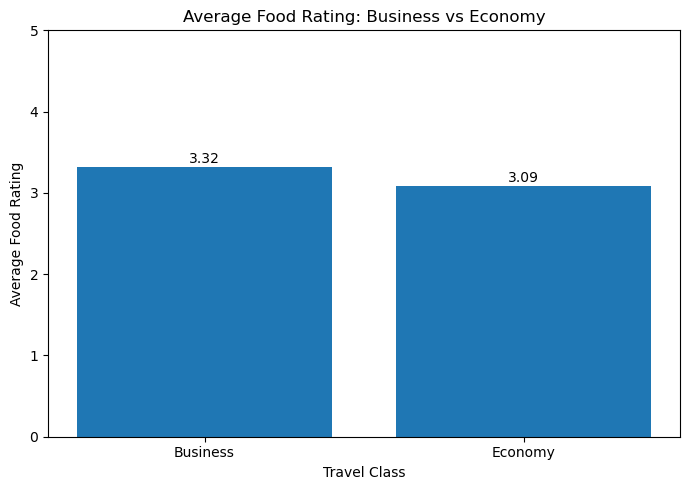

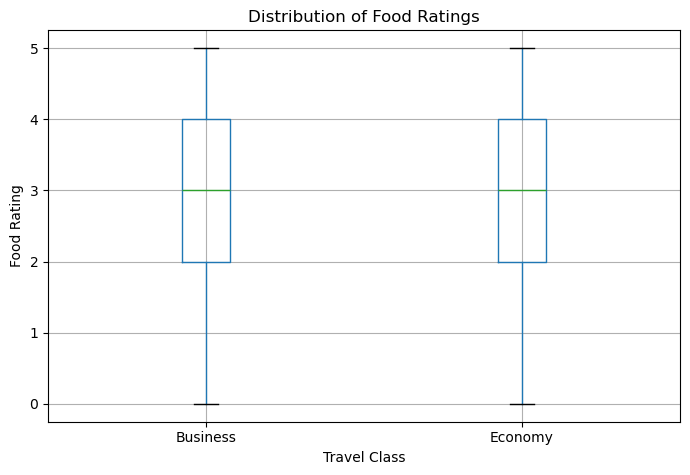


Welch's t-test
T-statistic: 25.012
P-value: 1.5994089185975489e-137
Result: Food ratings differ significantly between Business and Economy classes.


In [9]:
# ==========================================================
# Food Rating: Business vs Economy
# ==========================================================

food_data = df[
    df["Travel Class"].isin(
        ["Business", "Economy"]
    )
][["Travel Class", "Food"]].dropna()


# Summary statistics
food_summary = (
    food_data
    .groupby("Travel Class")["Food"]
    .agg(
        ["count", "mean", "median", "std"]
    )
    .round(2)
)

print("Food Rating Summary:")
print(food_summary)


# Average rating
food_rating_avg = (
    food_data
    .groupby("Travel Class")["Food"]
    .mean()
    .round(2)
)

print("\nAverage Food Rating:")
print(food_rating_avg)


# Bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    food_rating_avg.index,
    food_rating_avg.values
)

plt.title(
    "Average Food Rating: Business vs Economy"
)

plt.xlabel("Travel Class")
plt.ylabel("Average Food Rating")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.ylim(0, 5)
plt.tight_layout()
plt.show()


# Box plot
food_data.boxplot(
    column="Food",
    by="Travel Class",
    figsize=(7, 5)
)

plt.title(
    "Distribution of Food Ratings"
)

plt.suptitle("")
plt.xlabel("Travel Class")
plt.ylabel("Food Rating")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# Welch's Independent t-test
# ----------------------------------------------------------

business_food = food_data.loc[
    food_data["Travel Class"] == "Business",
    "Food"
]

economy_food = food_data.loc[
    food_data["Travel Class"] == "Economy",
    "Food"
]

t_stat, p_value = ttest_ind(
    business_food,
    economy_food,
    equal_var=False
)

print("\nWelch's t-test")
print("T-statistic:", round(t_stat, 3))
print("P-value:", p_value)

if p_value < 0.05:

    print(
        "Result: Food ratings differ significantly "
        "between Business and Economy classes."
    )

else:

    print(
        "Result: No significant difference was found."
    )

Average Delays:
Departure Delay (min)    14.82
Arrival Delay (min)      15.18
dtype: float64


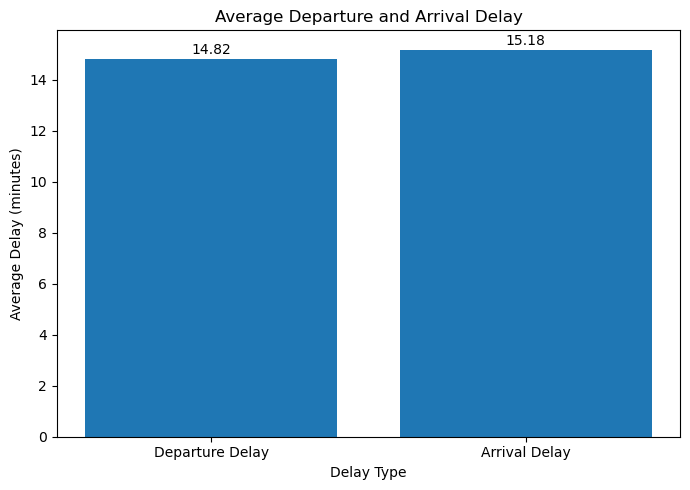

In [10]:
# ==========================================================
# Average Departure and Arrival Delay
# ==========================================================

average_delays = df[
    [
        "Departure Delay (min)",
        "Arrival Delay (min)"
    ]
].mean().round(2)

print("Average Delays:")
print(average_delays)


# Visualisation
plt.figure(figsize=(7, 5))

bars = plt.bar(
    [
        "Departure Delay",
        "Arrival Delay"
    ],
    average_delays.values
)

plt.title(
    "Average Departure and Arrival Delay"
)

plt.xlabel("Delay Type")
plt.ylabel("Average Delay (minutes)")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Average Delays by Satisfaction:
              Departure Delay (min)  Arrival Delay (min)
Satisfaction                                            
dissatisfied                  16.50                17.13
satisfied                     12.61                12.63


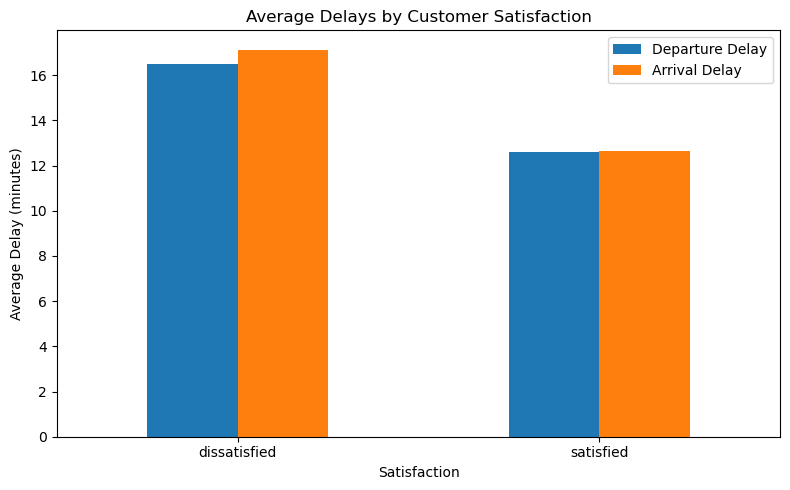


Satisfaction Percentage by Delay Group:
Satisfaction  dissatisfied  satisfied
Delay Group                          
No Delay             53.06      46.94
1-15 min             54.89      45.11
16-30 min            61.53      38.47
31-60 min            64.35      35.65
60+ min              64.07      35.93


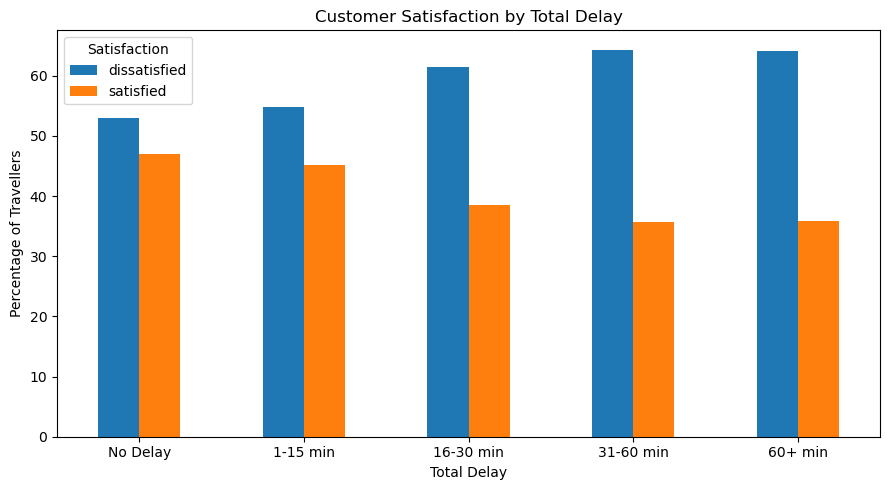


Welch t-test for Departure Delay (min)
T-statistic: 16.575
P-value: 1.2767076513247507e-61

Welch t-test for Arrival Delay (min)
T-statistic: 18.862
P-value: 3.17596052633531e-79

Correlation: Departure Delay (min)
Correlation: -0.05
P-value: 1.229345549674652e-59

Correlation: Arrival Delay (min)
Correlation: -0.058
P-value: 8.391469906735666e-77

Chi-square Test:
Chi-square: 892.68
P-value: 6.412776847941494e-192
Delay level and satisfaction are significantly associated.


In [11]:
# ==========================================================
# Impact of Delays on Customer Satisfaction
# ==========================================================

delay_df = df.copy()

delay_df["Satisfaction"] = (
    delay_df["Satisfaction"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ----------------------------------------------------------
# Average delay by satisfaction
# ----------------------------------------------------------

delay_summary = (
    delay_df.groupby("Satisfaction")[
        [
            "Departure Delay (min)",
            "Arrival Delay (min)"
        ]
    ]
    .mean()
    .round(2)
)

print(
    "Average Delays by Satisfaction:"
)

print(delay_summary)


# Visualisation
delay_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Average Delays by Customer Satisfaction"
)

plt.xlabel("Satisfaction")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=0)

plt.legend(
    [
        "Departure Delay",
        "Arrival Delay"
    ]
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# Create Total Delay
# ----------------------------------------------------------
# min_count=2 means Total Delay is missing if
# either departure or arrival delay is missing.

delay_df["Total Delay"] = (
    delay_df[
        [
            "Departure Delay (min)",
            "Arrival Delay (min)"
        ]
    ]
    .sum(
        axis=1,
        min_count=2
    )
)


# ----------------------------------------------------------
# Create Delay Groups
# ----------------------------------------------------------

delay_bins = [
    -1,
    0,
    15,
    30,
    60,
    np.inf
]

delay_labels = [
    "No Delay",
    "1-15 min",
    "16-30 min",
    "31-60 min",
    "60+ min"
]

delay_df["Delay Group"] = pd.cut(
    delay_df["Total Delay"],
    bins=delay_bins,
    labels=delay_labels
)


# Satisfaction percentage
delay_satisfaction = (
    pd.crosstab(
        delay_df["Delay Group"],
        delay_df["Satisfaction"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print(
    "\nSatisfaction Percentage by Delay Group:"
)

print(delay_satisfaction)


# Visualisation
delay_satisfaction.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Customer Satisfaction by Total Delay"
)

plt.xlabel("Total Delay")
plt.ylabel("Percentage of Travellers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# Welch t-tests
# ----------------------------------------------------------

for column in [
    "Departure Delay (min)",
    "Arrival Delay (min)"
]:

    satisfied = delay_df.loc[
        delay_df["Satisfaction"]
        == "satisfied",
        column
    ].dropna()

    dissatisfied = delay_df.loc[
        delay_df["Satisfaction"]
        == "dissatisfied",
        column
    ].dropna()

    t_stat, p_value = ttest_ind(
        dissatisfied,
        satisfied,
        equal_var=False
    )

    print(
        f"\nWelch t-test for {column}"
    )

    print(
        "T-statistic:",
        round(t_stat, 3)
    )

    print(
        "P-value:",
        p_value
    )


# ----------------------------------------------------------
# Correlation with satisfaction
# ----------------------------------------------------------

satisfaction_numeric = (
    delay_df["Satisfaction"]
    .map({
        "dissatisfied": 0,
        "satisfied": 1
    })
)

for column in [
    "Departure Delay (min)",
    "Arrival Delay (min)"
]:

    temp = pd.DataFrame({
        "Delay": delay_df[column],
        "Satisfaction": satisfaction_numeric
    }).dropna()

    correlation, p_value = pointbiserialr(
        temp["Satisfaction"],
        temp["Delay"]
    )

    print(
        f"\nCorrelation: {column}"
    )

    print(
        "Correlation:",
        round(correlation, 3)
    )

    print(
        "P-value:",
        p_value
    )


# ----------------------------------------------------------
# Chi-square: Delay Group vs Satisfaction
# ----------------------------------------------------------

contingency_table = pd.crosstab(
    delay_df["Delay Group"],
    delay_df["Satisfaction"]
)

chi2, p_value, dof, expected = (
    chi2_contingency(
        contingency_table
    )
)

print(
    "\nChi-square Test:"
)

print(
    "Chi-square:",
    round(chi2, 2)
)

print(
    "P-value:",
    p_value
)

if p_value < 0.05:

    print(
        "Delay level and satisfaction "
        "are significantly associated."
    )

In [12]:
# ==========================================================
# MODEL BUILDING - DATA CLEANING
# ==========================================================

# IMPORTANT:
# Reload the ORIGINAL raw dataset.
# This prevents EDA-created columns from entering
# the model-building dataset.

df_model = pd.read_csv(DATA_PATH)

print(
    "Original Raw Dataset Shape:",
    df_model.shape
)


# ----------------------------------------------------------
# 1. Clean column text values
# ----------------------------------------------------------

text_columns = [
    "Gender",
    "Travel Category",
    "Travel Class",
    "Satisfaction"
]

for column in text_columns:

    df_model[column] = (
        df_model[column]
        .astype("string")
        .str.strip()
    )


# ----------------------------------------------------------
# 2. Ensure numerical data types
# ----------------------------------------------------------

numerical_columns = [
    "id",
    "Age",
    "Distance Travelled",
    "Departure/Arrival Rating",
    "Booking Ease",
    "Boarding Point",
    "Food",
    "Seat Comfort",
    "Entertainment",
    "Leg Room",
    "Luggage Handling",
    "Cleanliness",
    "Departure Delay (min)",
    "Arrival Delay (min)"
]

for column in numerical_columns:

    df_model[column] = pd.to_numeric(
        df_model[column],
        errors="coerce"
    )


# ----------------------------------------------------------
# 3. Identify missing values
# ----------------------------------------------------------

missing_summary = pd.DataFrame({

    "Missing Count":
        df_model.isnull().sum(),

    "Missing Percentage":
        (
            df_model.isnull().mean()
            * 100
        ).round(2)

})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

print(
    "\nMissing Values Before Cleaning:"
)

print(missing_summary)


# ----------------------------------------------------------
# 4. Remove missing target values
# ----------------------------------------------------------

df_model = df_model.dropna(
    subset=["Satisfaction"]
)


# ----------------------------------------------------------
# 5. Handle categorical missing values
# ----------------------------------------------------------

categorical_columns = [
    "Gender",
    "Travel Category",
    "Travel Class"
]

for column in categorical_columns:

    if df_model[column].isnull().sum() > 0:

        mode_value = (
            df_model[column]
            .mode()[0]
        )

        df_model[column] = (
            df_model[column]
            .fillna(mode_value)
        )

        print(
            f"{column}: filled using mode "
            f"({mode_value})"
        )


# ----------------------------------------------------------
# 6. Handle numerical missing values
# ----------------------------------------------------------

numerical_predictors = [
    "Age",
    "Distance Travelled",
    "Departure/Arrival Rating",
    "Booking Ease",
    "Boarding Point",
    "Food",
    "Seat Comfort",
    "Entertainment",
    "Leg Room",
    "Luggage Handling",
    "Cleanliness",
    "Departure Delay (min)",
    "Arrival Delay (min)"
]

for column in numerical_predictors:

    if df_model[column].isnull().sum() > 0:

        median_value = (
            df_model[column]
            .median()
        )

        df_model[column] = (
            df_model[column]
            .fillna(median_value)
        )

        print(
            f"{column}: filled using median "
            f"({median_value})"
        )


# ----------------------------------------------------------
# 7. Remove duplicates
# ----------------------------------------------------------

print(
    "\nDuplicate Rows:",
    df_model.duplicated().sum()
)

df_model = (
    df_model
    .drop_duplicates()
    .copy()
)


# ----------------------------------------------------------
# 8. Convert categorical columns
# ----------------------------------------------------------

for column in [
    "Gender",
    "Travel Category",
    "Travel Class",
    "Satisfaction"
]:

    df_model[column] = (
        df_model[column]
        .astype("category")
    )


# ----------------------------------------------------------
# 9. Handle Outliers using IQR
# ----------------------------------------------------------
# Rule from assignment:
#
# < 5% outliers -> REMOVE
# >= 5% outliers -> RETAIN
# ----------------------------------------------------------

outlier_columns = [
    "Age",
    "Distance Travelled",
    "Departure Delay (min)",
    "Arrival Delay (min)"
]

remove_mask = pd.Series(
    False,
    index=df_model.index
)

outlier_results = []

for column in outlier_columns:

    Q1 = df_model[column].quantile(0.25)
    Q3 = df_model[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = (
        Q1 - 1.5 * IQR
    )

    upper_limit = (
        Q3 + 1.5 * IQR
    )

    column_outliers = (
        (df_model[column] < lower_limit)
        |
        (df_model[column] > upper_limit)
    )

    outlier_count = (
        column_outliers.sum()
    )

    outlier_percentage = (
        outlier_count
        / len(df_model)
        * 100
    )

    if (
        outlier_count > 0
        and
        outlier_percentage < 5
    ):

        action = "Removed"

        remove_mask = (
            remove_mask
            | column_outliers
        )

    elif outlier_percentage >= 5:

        action = "Retained"

    else:

        action = "No Outliers"

    outlier_results.append([
        column,
        outlier_count,
        round(
            outlier_percentage,
            2
        ),
        action
    ])


outlier_summary = pd.DataFrame(
    outlier_results,
    columns=[
        "Feature",
        "Outlier Count",
        "Outlier Percentage",
        "Action"
    ]
)

print(
    "\nOutlier Summary:"
)

print(outlier_summary)


# Remove eligible outlier rows
df_model = (
    df_model.loc[
        ~remove_mask
    ]
    .copy()
)


# ----------------------------------------------------------
# 10. Final Cleaning Verification
# ----------------------------------------------------------

print(
    "\nFinal Cleaned Dataset Shape:",
    df_model.shape
)

print(
    "Total Missing Values:",
    df_model.isnull().sum().sum()
)

print(
    "\nFinal Data Types:"
)

print(df_model.dtypes)


# ----------------------------------------------------------
# 11. Save Cleaned Data File
# ----------------------------------------------------------

df_model.to_csv(
    "Customer_Satisfaction_Cleaned.csv",
    index=False
)

print(
    "\nCleaned dataset saved successfully."
)

Original Raw Dataset Shape: (103904, 18)

Missing Values Before Cleaning:
                          Missing Count  Missing Percentage
Travel Class                       6283                6.05
Departure/Arrival Rating          12170               11.71
Booking Ease                      12149               11.69
Boarding Point                     9209                8.86
Food                              13958               13.43
Seat Comfort                      10136                9.76
Entertainment                      8231                7.92
Leg Room                          15272               14.70
Luggage Handling                   8253                7.94
Arrival Delay (min)                 310                0.30
Travel Class: filled using mode (Business)
Departure/Arrival Rating: filled using median (3.0)
Booking Ease: filled using median (3.0)
Boarding Point: filled using median (3.0)
Food: filled using median (3.0)
Seat Comfort: filled using median (4.0)
Entertainment: fi

In [13]:
# ==========================================================
# DATA PREPARATION
# ==========================================================

# Target variable
y = (
    df_model["Satisfaction"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "dissatisfied": 0,
        "satisfied": 1
    })
)

print(
    "Target Distribution:"
)

print(
    y.value_counts()
)


# Features
X = df_model.drop(
    columns=[
        "id",
        "Satisfaction"
    ]
)


# Identify categorical predictors
categorical_features = (
    X.select_dtypes(
        include=[
            "object",
            "category",
            "string"
        ]
    )
    .columns
)

print(
    "\nCategorical Features:"
)

print(
    categorical_features.tolist()
)


# One-hot encoding
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print(
    "\nX Shape Before Feature Engineering:",
    X.shape
)

print(
    "y Shape:",
    y.shape
)

Target Distribution:
Satisfaction
0    58045
1    42209
Name: count, dtype: int64

Categorical Features:
['Gender', 'Travel Category', 'Travel Class']

X Shape Before Feature Engineering: (100254, 17)
y Shape: (100254,)


In [14]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================


# ----------------------------------------------------------
# 1. Total Delay
# ----------------------------------------------------------

X["Total Delay"] = (
    X["Departure Delay (min)"]
    +
    X["Arrival Delay (min)"]
)


# ----------------------------------------------------------
# 2. Average Service Rating
# ----------------------------------------------------------

rating_columns = [
    "Departure/Arrival Rating",
    "Booking Ease",
    "Boarding Point",
    "Food",
    "Seat Comfort",
    "Entertainment",
    "Leg Room",
    "Luggage Handling",
    "Cleanliness"
]

X["Average Service Rating"] = (
    X[rating_columns]
    .mean(axis=1)
)


# ----------------------------------------------------------
# 3. Interaction Feature
# ----------------------------------------------------------

X["Comfort Interaction"] = (
    X["Seat Comfort"]
    *
    X["Leg Room"]
)


print(
    "New Engineered Features:"
)

print(
    X[
        [
            "Total Delay",
            "Average Service Rating",
            "Comfort Interaction"
        ]
    ].head()
)

New Engineered Features:
   Total Delay  Average Service Rating  Comfort Interaction
0         43.0                4.000000                 20.0
1          7.0                2.555556                 20.0
2          0.0                3.666667                 15.0
3         20.0                3.555556                 10.0
4          0.0                3.444444                 20.0


Distance Category Distribution:
Distance Category
Short        43878
Medium       25255
Long         18402
Very Long    12719
Name: count, dtype: int64


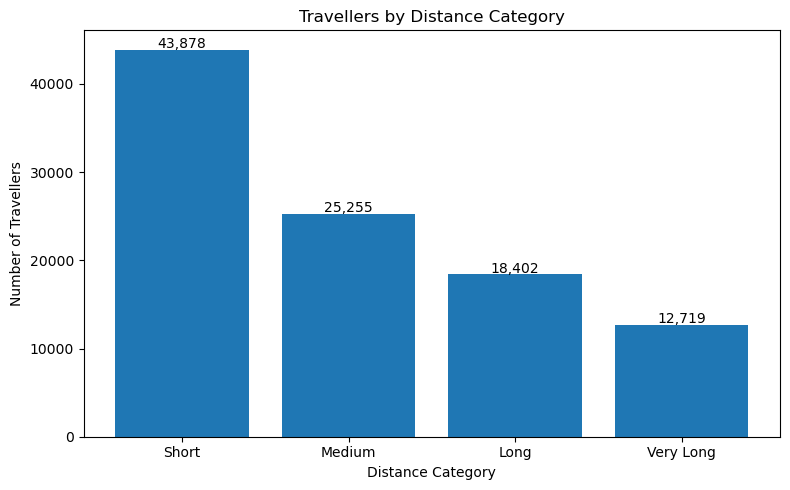


Final Feature Shape: (100254, 23)


In [15]:
# ==========================================================
# FEATURE BINNING
# Distance Travelled
# ==========================================================

distance_bins = [
    -np.inf,
    500,
    1000,
    2000,
    np.inf
]

distance_labels = [
    "Short",
    "Medium",
    "Long",
    "Very Long"
]


# Create distance category
X["Distance Category"] = pd.cut(
    X["Distance Travelled"],
    bins=distance_bins,
    labels=distance_labels
)


# Display counts
distance_category_counts = (
    X["Distance Category"]
    .value_counts(sort=False)
)

print(
    "Distance Category Distribution:"
)

print(
    distance_category_counts
)


# Visualisation
plt.figure(figsize=(8, 5))

bars = plt.bar(
    distance_category_counts.index.astype(str),
    distance_category_counts.values
)

plt.title(
    "Travellers by Distance Category"
)

plt.xlabel("Distance Category")
plt.ylabel("Number of Travellers")

for bar in bars:

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# Convert Distance Category to numerical dummy columns
X = pd.get_dummies(
    X,
    columns=["Distance Category"],
    drop_first=True,
    dtype=int
)


print(
    "\nFinal Feature Shape:",
    X.shape
)

Satisfaction Counts:
Satisfaction
dissatisfied    58045
satisfied       42209
Name: count, dtype: int64

Satisfaction Percentage:
Satisfaction
dissatisfied    57.9
satisfied       42.1
Name: proportion, dtype: float64


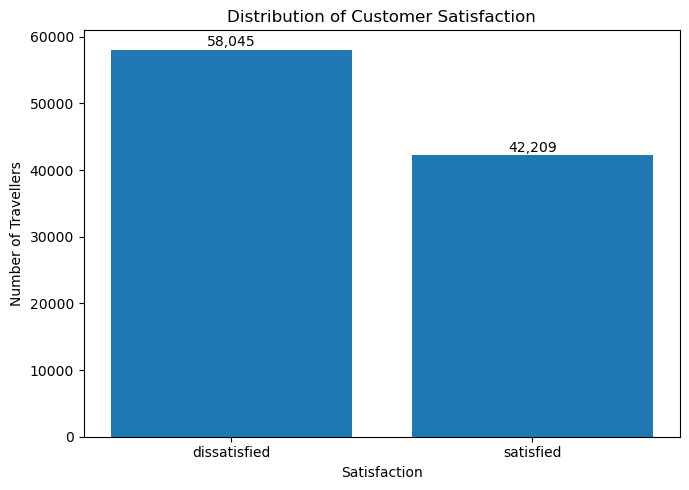

In [16]:
# ==========================================================
# EDA 1
# Visualise distribution of target variable
# ==========================================================

target_counts = (
    df_model["Satisfaction"]
    .value_counts()
)

target_percentage = (
    df_model["Satisfaction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(
    "Satisfaction Counts:"
)

print(target_counts)

print(
    "\nSatisfaction Percentage:"
)

print(target_percentage)


# Visualisation
plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_counts.index.astype(str),
    target_counts.values
)

plt.title(
    "Distribution of Customer Satisfaction"
)

plt.xlabel("Satisfaction")
plt.ylabel("Number of Travellers")

for bar in bars:

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Top 10 Features Correlated with Satisfaction:
Travel Category_Personal Travel   -0.445161
Travel Class_Economy              -0.420401
Comfort Interaction                0.410221
Average Service Rating             0.381803
Entertainment                      0.369536
Seat Comfort                       0.321039
Cleanliness                        0.298401
Leg Room                           0.274403
Distance Travelled                 0.228934
Luggage Handling                   0.226913
dtype: float64


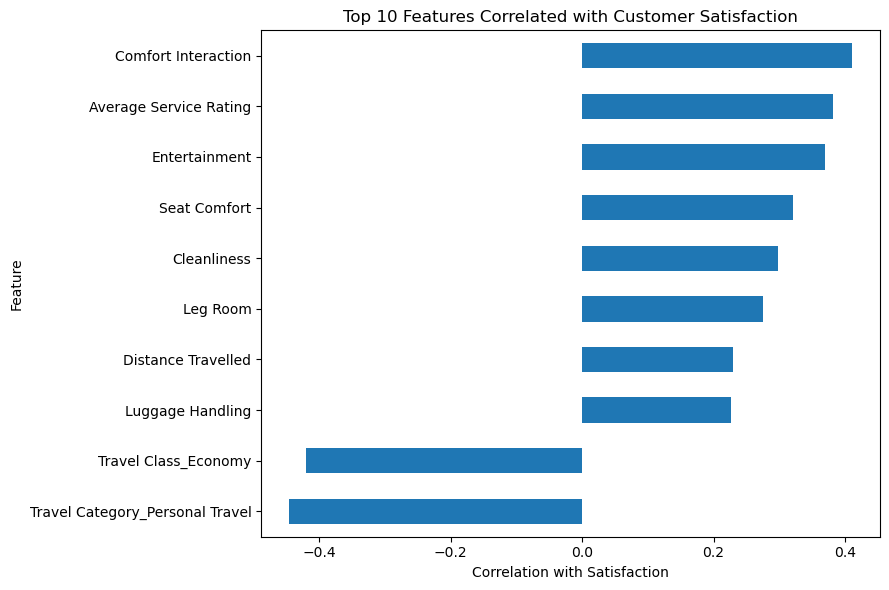

In [17]:
# ==========================================================
# EDA 2
# Correlations with Satisfaction
# ==========================================================

correlations = (
    X.corrwith(y)
    .dropna()
)


# Select actual top 10
top_10_features = (
    correlations
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
    .index
)

top_10 = correlations.loc[
    top_10_features
].sort_values()


print(
    "Top 10 Features Correlated "
    "with Satisfaction:"
)

print(
    top_10
    .sort_values(
        key=abs,
        ascending=False
    )
)


# Corrected visualisation:
# plot top_10 rather than all correlations

plt.figure(figsize=(9, 6))

top_10.plot(
    kind="barh"
)

plt.title(
    "Top 10 Features Correlated with Customer Satisfaction"
)

plt.xlabel(
    "Correlation with Satisfaction"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Outlier Analysis:

Age
Outlier Count: 0
Outlier Percentage: 0.0 %

Distance Travelled
Outlier Count: 2385
Outlier Percentage: 2.38 %

Departure Delay (min)
Outlier Count: 14005
Outlier Percentage: 13.97 %

Arrival Delay (min)
Outlier Count: 13467
Outlier Percentage: 13.43 %


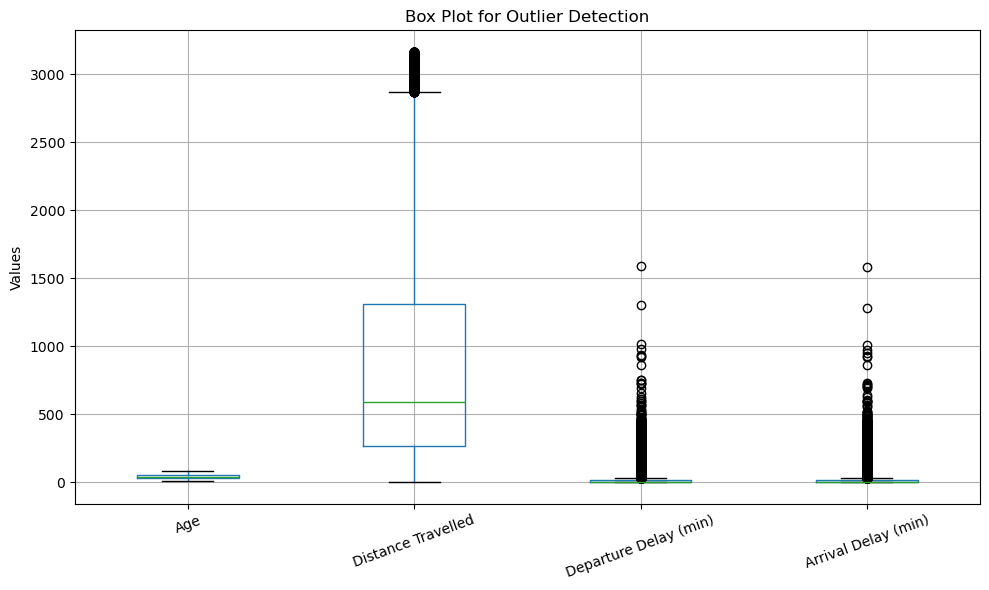

In [18]:
# ==========================================================
# EDA 3
# Identify Outliers
# ==========================================================

eda_outlier_columns = [
    "Age",
    "Distance Travelled",
    "Departure Delay (min)",
    "Arrival Delay (min)"
]

print(
    "Outlier Analysis:"
)

for column in eda_outlier_columns:

    Q1 = df_model[column].quantile(0.25)
    Q3 = df_model[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = (
        Q1 - 1.5 * IQR
    )

    upper_limit = (
        Q3 + 1.5 * IQR
    )

    outliers = df_model[
        (df_model[column] < lower_limit)
        |
        (df_model[column] > upper_limit)
    ]

    percentage = (
        len(outliers)
        / len(df_model)
        * 100
    )

    print(
        f"\n{column}"
    )

    print(
        "Outlier Count:",
        len(outliers)
    )

    print(
        "Outlier Percentage:",
        round(percentage, 2),
        "%"
    )


# Visualise outliers
plt.figure(figsize=(10, 6))

df_model[
    eda_outlier_columns
].boxplot()

plt.title(
    "Box Plot for Outlier Detection"
)

plt.ylabel("Values")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Satisfaction Rate by Delay Group:
Delay Group
No Delay     45.61
1-15 min     43.93
16-30 min    37.48
31-60 min    34.58
60+ min      34.68
Name: Satisfaction, dtype: float64


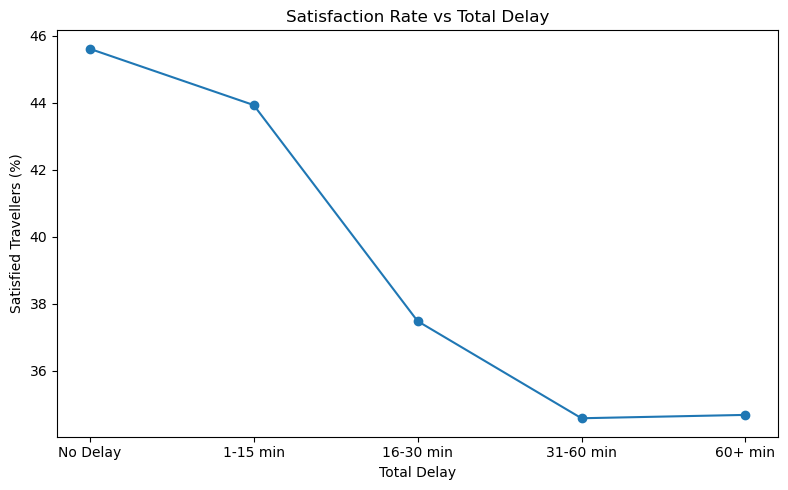

In [19]:
# ==========================================================
# EDA 4
# Trend: Satisfaction versus Total Delay
# ==========================================================

eda_df = df_model.copy()

eda_df["Total Delay"] = (
    eda_df["Departure Delay (min)"]
    +
    eda_df["Arrival Delay (min)"]
)


delay_bins = [
    -1,
    0,
    15,
    30,
    60,
    np.inf
]

delay_labels = [
    "No Delay",
    "1-15 min",
    "16-30 min",
    "31-60 min",
    "60+ min"
]

eda_df["Delay Group"] = pd.cut(
    eda_df["Total Delay"],
    bins=delay_bins,
    labels=delay_labels
)


delay_trend = (
    eda_df.groupby(
        "Delay Group",
        observed=False
    )["Satisfaction"]
    .apply(
        lambda x:
        (
            x.astype(str)
            .str.lower()
            == "satisfied"
        ).mean() * 100
    )
    .round(2)
)


print(
    "Satisfaction Rate by Delay Group:"
)

print(delay_trend)


# Visualisation
plt.figure(figsize=(8, 5))

plt.plot(
    delay_trend.index.astype(str),
    delay_trend.values,
    marker="o"
)

plt.title(
    "Satisfaction Rate vs Total Delay"
)

plt.xlabel("Total Delay")
plt.ylabel("Satisfied Travellers (%)")

plt.tight_layout()
plt.show()

In [20]:
# ==========================================================
# TARGET LEAKAGE CHECK
# ==========================================================

possible_leakage = [
    column
    for column in X.columns
    if "satisfaction"
    in column.lower()
]

non_numeric_columns = (
    X.select_dtypes(
        exclude="number"
    )
    .columns
    .tolist()
)

print(
    "Possible Satisfaction Columns in X:"
)

print(
    possible_leakage
)

print(
    "\nNon-Numerical Columns:"
)

print(
    non_numeric_columns
)


if (
    len(possible_leakage) == 0
    and
    len(non_numeric_columns) == 0
):

    print(
        "\nData is ready for model training."
    )

else:

    print(
        "\nWARNING: Check X before training."
    )

Possible Satisfaction Columns in X:
[]

Non-Numerical Columns:
[]

Data is ready for model training.


In [21]:
# ==========================================================
# MODEL TRAINING
# Split into Training and Testing Sets
# ==========================================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Training Data:",
    X_train.shape
)

print(
    "Testing Data:",
    X_test.shape
)

Training Data: (80203, 23)
Testing Data: (20051, 23)


In [22]:
# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train_scaled = (
    scaler.fit_transform(
        X_train
    )
)

X_test_scaled = (
    scaler.transform(
        X_test
    )
)

print(
    "Feature scaling completed."
)

Feature scaling completed.


In [23]:
# ==========================================================
# TRAIN MULTIPLE MODELS
# ==========================================================

models = {

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
}


results = []

predictions = {}


for name, model in models.items():

    # Tree-based models use original features
    if name in [
        "Decision Tree",
        "Random Forest"
    ]:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

    # KNN and Logistic Regression
    # use scaled features
    else:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )


    # Save predictions
    predictions[name] = y_pred


    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )


    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [24]:
# ==========================================================
# MODEL PERFORMANCE METRICS
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] = results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(4)


print(
    "Model Evaluation Results:"
)

print(
    results_df
)

Model Evaluation Results:
                 Model  Accuracy  Precision  Recall  F1 Score
0        Decision Tree    0.8414     0.8091  0.8156    0.8123
1        Random Forest    0.8919     0.8927  0.8448    0.8681
2                  KNN    0.8573     0.8558  0.7950    0.8242
3  Logistic Regression    0.8186     0.7902  0.7747    0.7824


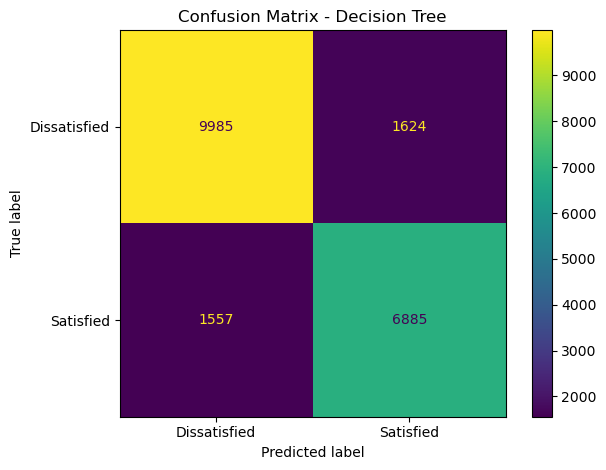

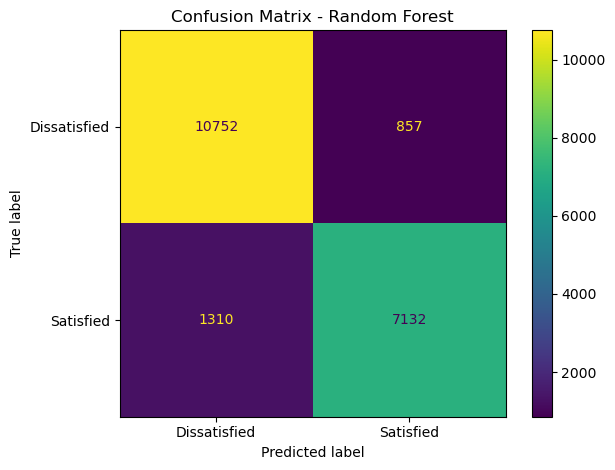

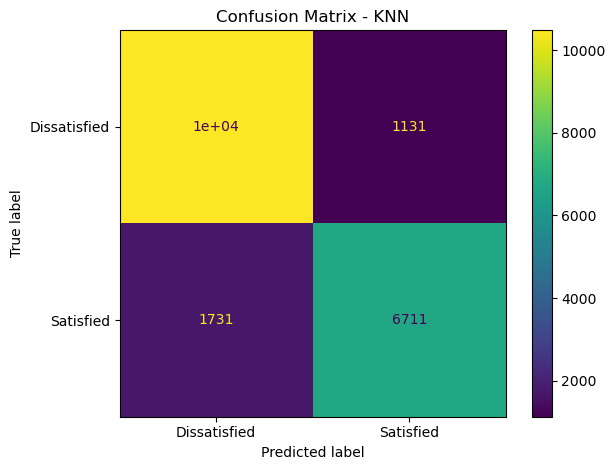

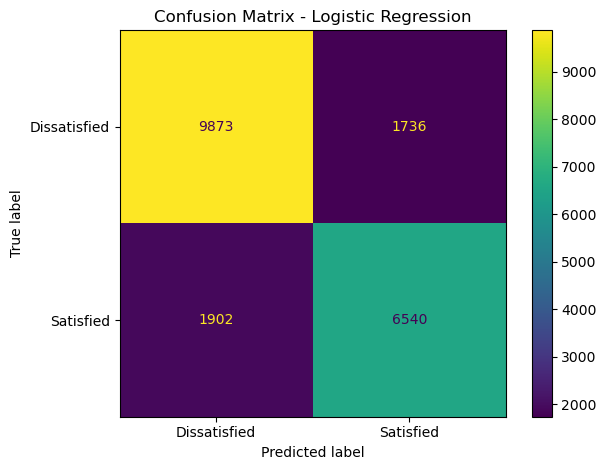

In [25]:
# ==========================================================
# CONFUSION MATRICES
# ==========================================================

for name, y_pred in predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=[
            "Dissatisfied",
            "Satisfied"
        ]
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.tight_layout()
    plt.show()

In [26]:
# ==========================================================
# SELECT BEST MODEL
# ==========================================================

best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print(
    "Best Model:"
)

print(
    best_model
)

print(
    "\nThe best-performing model is",
    best_model["Model"]
)

print(
    "Accuracy:",
    best_model["Accuracy"]
)

print(
    "Precision:",
    best_model["Precision"]
)

print(
    "Recall:",
    best_model["Recall"]
)

print(
    "F1 Score:",
    best_model["F1 Score"]
)

Best Model:
Model        Random Forest
Accuracy            0.8919
Precision           0.8927
Recall              0.8448
F1 Score            0.8681
Name: 1, dtype: object

The best-performing model is Random Forest
Accuracy: 0.8919
Precision: 0.8927
Recall: 0.8448
F1 Score: 0.8681


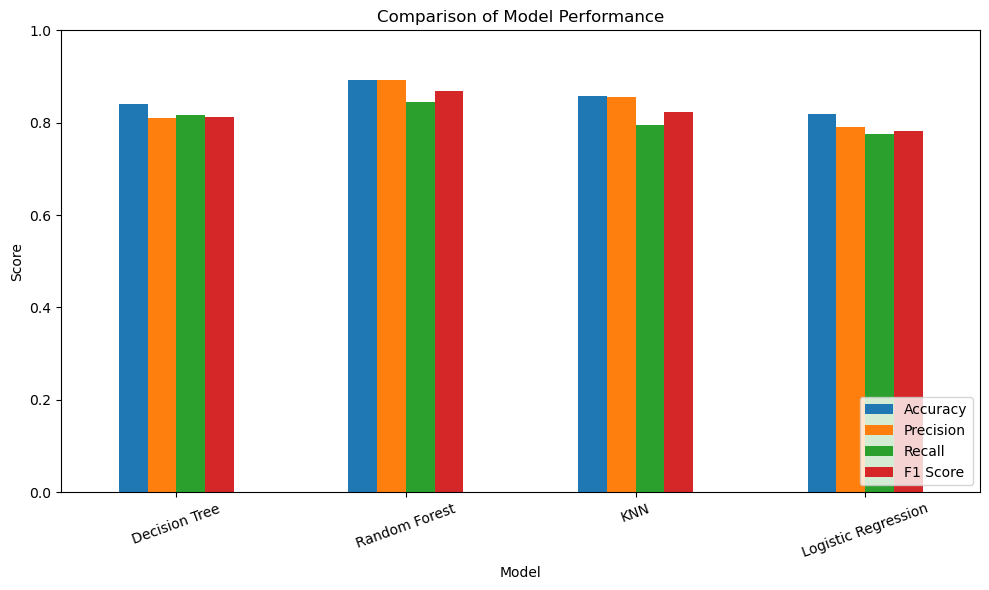

In [27]:
# ==========================================================
# VISUAL COMPARISON OF MODEL PERFORMANCE
# ==========================================================

results_plot = (
    results_df
    .set_index("Model")
)

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Comparison of Model Performance"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=20
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [28]:
# ==========================================================
# FINAL MODEL SUMMARY
# ==========================================================

print(
    "FINAL CONCLUSION"
)

print(
    "\nBest Model:",
    best_model["Model"]
)

print(
    "Accuracy:",
    f"{best_model['Accuracy'] * 100:.2f}%"
)

print(
    "Precision:",
    f"{best_model['Precision'] * 100:.2f}%"
)

print(
    "Recall:",
    f"{best_model['Recall'] * 100:.2f}%"
)

print(
    "F1 Score:",
    f"{best_model['F1 Score'] * 100:.2f}%"
)

print(
    "\nPossible improvements:"
)

print(
    "- Cross-validation"
)

print(
    "- Hyperparameter tuning"
)

print(
    "- Feature importance analysis"
)

print(
    "- Testing on completely unseen data"
)

FINAL CONCLUSION

Best Model: Random Forest
Accuracy: 89.19%
Precision: 89.27%
Recall: 84.48%
F1 Score: 86.81%

Possible improvements:
- Cross-validation
- Hyperparameter tuning
- Feature importance analysis
- Testing on completely unseen data
